# Localization

In [21]:
%reset -f
%run pylib/tools dark
from utilities.ipynb_docgen import show
from importlib import reload
from like3 import likelihood as lk; reload(lk);
from like3.sourcelist import SourceList
from like3 import bands as bd; reload(bd)
from like3.bands import Band, BandList

bl = BandList.psf_demo()
self = lk.Likelihood(model=bl, data=bl.simulate(42))
self.maximize(); show(self.fit_info)

Model: 2 sources, 4 free parameters
Creating BandList with PSF for model: 2 sources, 4 free parameters
Counts per band: [7787 5897 4419 3130 1978 1043  424  130   38   17    9    5]


{'cov': array([[ 8.19952941e-05, -3.79232283e-05, -1.93023359e-04,  1.02540011e-04],
        [-3.79232283e-05,  4.66653742e-04, -3.73249945e-04, -5.41889283e-04],
        [-1.93023359e-04, -3.73249945e-04,  1.18758513e-03,  4.37737923e-06],
        [ 1.02540011e-04, -5.41889283e-04,  4.37737923e-06,  1.10694920e-03]]),
 'sigs': array([0.00905513, 0.02160217, 0.03446136, 0.03327085]),
 'corr': array([[ 1.  , -0.19, -0.62,  0.34],
        [-0.19,  1.  , -0.5 , -0.75],
        [-0.62, -0.5 ,  1.  ,  0.  ],
        [ 0.34, -0.75,  0.  ,  1.  ]]),
 'grad': array([-0.08906549,  0.47445457,  0.2332356 , -0.65640481]),
 'x_fit': array([-10.99855733,   2.00737936, -11.41619059,   1.99977342]),
 'delta_loglike': 0.18,
 'funcalls': 11,
 'ts_values': array([32450.4,     nan,  2866.7,     nan])}

<Figure size 864x288 with 0 Axes>

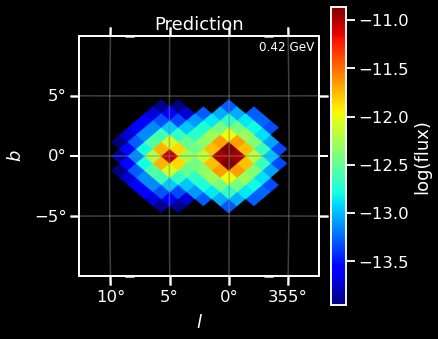

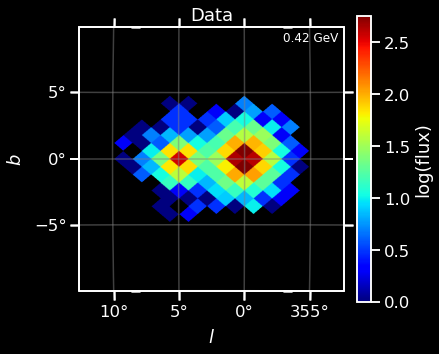

In [ ]:
band, exposure = bl[2], bl.exposure_factor[2]

fig = plt.figure(figsize=(12,4))
sfig1, sfig2 = fig.subfigures(1,2)

# WHy doesn't this work? I want to plot the prediction and data side by side, 
# but the second call to plot_pixel_map seems to overwrite the first one. 
# I thought I had fixed this by adding a fig argument to plot_pixel_map, but it doesn't seem to be working. Any ideas?
# band.plot_pixel_map(center=(2.5,0),  size=20, title='Prediction', fig=sfig1)
# data = band.simulate( exposure=exposure, random_state=42)
# band.plot_pixel_map(center=(2.5,0), data=data, size=20, title='Data', fig=sfig2)
# plt.show()    

band.plot_pixel_map(center=(2.5,0),  size=20, title='Prediction')
data = band.simulate( exposure=exposure, random_state=42)
band.plot_pixel_map(center=(2.5,0), data=data, size=20, title='Data')
show(f"""## Gradient evaluation""")
self = band

g = band.pixel_gradient( data, )
print('g shape:', g.shape)

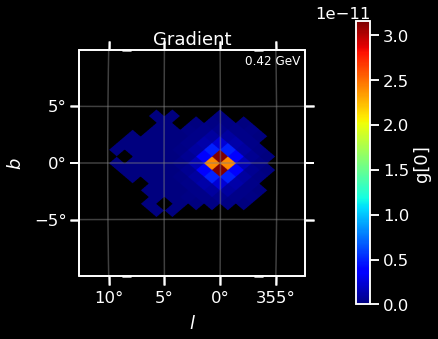

In [24]:
band.plot_pixel_map(center=(2.5,0), data=dict(zip(data[0], g[:,0])), size=20, log=False, 
                    label='g[0]',title='Gradient')

In [28]:
show(f"""## Full simulation""")
random_state = 42
self = bl
sim_data = dict()
for band, exposure in zip(self, self.exposure_factor):
    k,v = band.simulate(exposure=exposure, random_state=random_state)
    sim_data[int(band.energy)] = (k,v)

pixcnt = np.array([len(b) for k,b in sim_data.values()])
print(f'Pixels per band: {pixcnt}, total: {pixcnt.sum()}')

## Full simulation

Pixels per band: [ 44  68 111 141 160 166  67  21  18   7   5   3], total: 811


In [26]:
self.count_gradient()

array([[ 1.12411451e+04,  9.85890823e+03,  8.09475052e+03,  6.03037883e+03,  3.88173017e+03,  2.01344857e+03,
         7.55978268e+02,  1.75751722e+02,  2.00212438e+01,  7.88927463e-01,  6.41106480e-03,  4.97507517e-06],
       [ 1.18283782e+04,  7.90036624e+03,  4.45841704e+03,  1.81532491e+03,  1.97717593e+02, -4.00354707e+02,
        -3.39367975e+02, -1.22835004e+02, -1.89981935e+01, -9.45855830e-01, -9.28907091e-03, -8.45218657e-06],
       [ 6.63704770e+03,  3.72507551e+03,  2.09231827e+03,  1.17743115e+03,  6.62060415e+02,  3.72544787e+02,
         2.09489907e+02,  1.17820265e+02,  6.62654225e+01,  3.72676341e+01,  2.09599229e+01,  1.17883321e+01],
       [ 5.81503845e+03,  2.32910963e+03,  7.83965605e+02,  1.47106761e+02, -8.28607205e+01, -1.39678796e+02,
        -1.30931946e+02, -1.03093127e+02, -7.45481377e+01, -5.12431763e+01, -3.40599502e+01, -2.21030940e+01]])

In [ ]:
def pixel_flux(self):
    """ Convert flux to counts per pixel using the exposure factor for each band
    """
    r = dict()
    for band in self:
        r[int(band.energy)] = band.pixel_flux()
    return r

pixel_flux(self)

{133: (array([1440, 1376, 1312, 1439, 1503, 1567, 1568, 1504, 1441, 1377, 1313, 1569, 1505, 1442, 1570, 1633, 1632, 1697,
         1696, 1760, 1823, 1824, 1695, 1759, 1631, 1694, 1566, 1630, 1502, 1438, 1375, 1311, 1184, 1248, 1506, 1443,
         1378, 1634, 1571, 1698, 1761, 1825, 1249, 1185, 1314]),
  array([7.42357177e-11, 1.17991074e-11, 3.18081243e-12, 7.40659753e-12, 5.04203131e-12, 5.02432100e-11, 7.42357177e-11,
         9.83408652e-11, 4.35245846e-11, 3.94115987e-12, 2.36705089e-12, 4.35245846e-11, 1.89410997e-11, 2.25995343e-12,
         2.25995343e-12, 3.94115987e-12, 1.17991074e-11, 2.36705089e-12, 3.18081243e-12, 9.30168009e-13, 5.67549436e-13,
         1.83346992e-13, 7.40659753e-12, 8.86959385e-13, 5.04203131e-12, 6.62130704e-13, 1.26391506e-12, 2.53184830e-13,
         2.53184830e-13, 6.62130704e-13, 8.86959385e-13, 5.67549436e-13, 1.83346992e-13, 9.30168009e-13, 5.37303921e-13,
         1.02495579e-13, 2.96183151e-13, 2.96183151e-13, 1.02495579e-13, 4.28107195e-13, 3.